In [3]:
# =========================================
# EJERCICIO 2 - PREDICCIÓN DE NIVEL DE GLUCOSA
# Versión mejorada: compara varias regresiones lineales
# =========================================

# 1. Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# =========================================
# 2. Cargar dataset
# =========================================
df = pd.read_csv("glucosa_data.csv")

print("Primeras filas del dataset:")
display(df.head())

print("Dimensiones del dataset:", df.shape)

print("\nColumnas:")
print(list(df.columns))

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos:")
print(df.isnull().sum())

print("\nEstadísticas descriptivas:")
display(df.describe())



Primeras filas del dataset:


,Edad,IMC,Actividad_Fisica,Nivel_Glucosa
0,42,13.466414,1,141.840332
1,67,23.455602,1,171.937432
2,71,25.765184,8,155.504232
3,48,24.079550,2,115.865231
4,35,24.426649,7,115.698730


Dimensiones del dataset: (2000, 4)

Columnas:
['Edad', 'IMC', 'Actividad_Fisica', 'Nivel_Glucosa']

Tipos de datos:
Edad                  int64
IMC                 float64
Actividad_Fisica      int64
Nivel_Glucosa       float64
dtype: object

Valores nulos:
Edad                0
IMC                 0
Actividad_Fisica    0
Nivel_Glucosa       0
dtype: int64

Estadísticas descriptivas:


,Edad,IMC,Actividad_Fisica,Nivel_Glucosa
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,49.157000,24.963329,4.664500,139.630129
std,17.544494,3.983588,2.912247,27.342945
min,20.000000,10.586717,0.000000,43.415924
25%,34.000000,22.344522,2.000000,119.067583
50%,50.000000,25.028701,5.000000,139.967314
75%,64.000000,27.751081,7.000000,159.208487
max,79.000000,39.430227,9.000000,227.560693


Comparación de modelos:


,Modelo,MSE,R2,R2_CV_Promedio
2,Lasso,233.664074,0.681411,0.681787
0,Regresion_Lineal,233.693000,0.681372,0.681786
1,Ridge,233.697207,0.681366,0.681788
3,ElasticNet,233.724267,0.681329,0.681785
5,Polinomica_Grado_2_Ridge,233.774508,0.681260,0.680681
4,Polinomica_Grado_2,233.885817,0.681109,0.680592


Mejor modelo encontrado: Lasso
MSE del mejor modelo: 233.6641
R² del mejor modelo: 0.6814

Intercepto del modelo lineal base: 65.86086530452523

Coeficientes del modelo lineal base:


,Variable,Coeficiente
0,Edad,1.226590
1,IMC,0.933373
2,Actividad_Fisica,-2.085276



Impacto de las variables:


,Variable,Coeficiente_Estandarizado,Impacto_Absoluto
0,Edad,21.570811,21.570811
2,Actividad_Fisica,-6.106122,6.106122
1,IMC,3.722529,3.722529


La variable con mayor impacto en el nivel de glucosa es: Edad


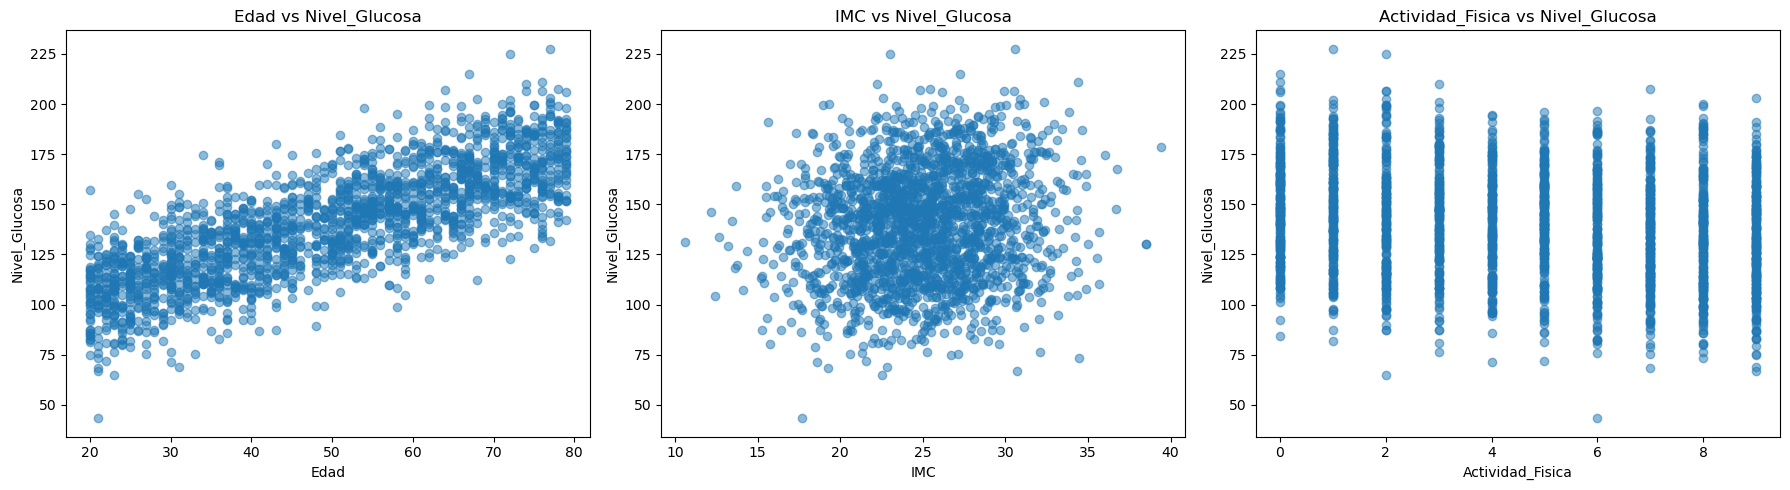

Matriz de correlación:


,Edad,IMC,Actividad_Fisica,Nivel_Glucosa
Edad,1.000000,0.015647,0.017783,0.789792
IMC,0.015647,1.000000,0.012829,0.138318
Actividad_Fisica,0.017783,0.012829,1.000000,-0.198395
Nivel_Glucosa,0.789792,0.138318,-0.198395,1.000000


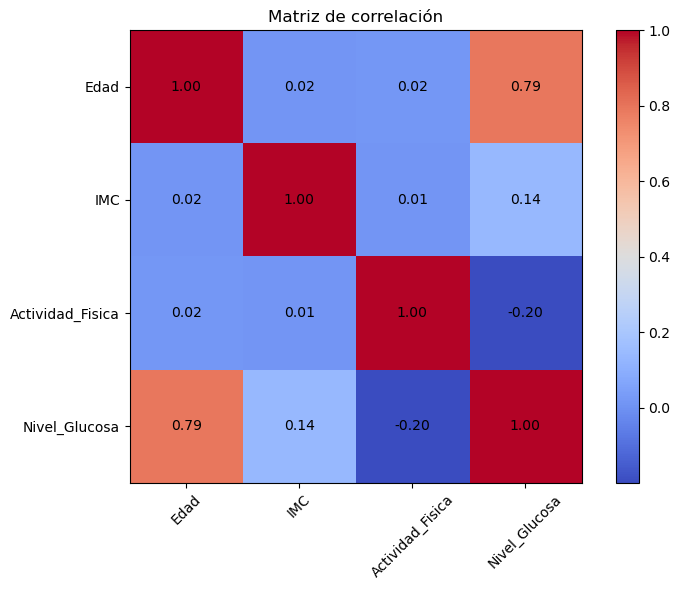

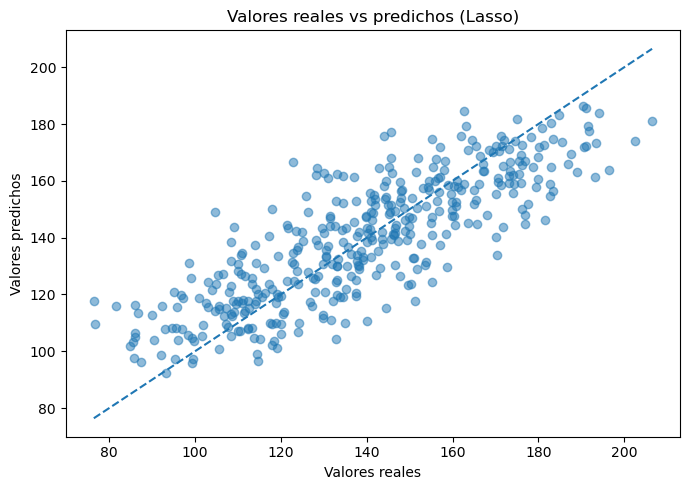

INTERPRETACIÓN DEL MODELO
----------------------------------------
Edad: tiene un efecto positivo sobre el nivel de glucosa (1.2266).
IMC: tiene un efecto positivo sobre el nivel de glucosa (0.9334).
Actividad_Fisica: tiene un efecto negativo sobre el nivel de glucosa (-2.0853).

MSE del mejor modelo: 233.6641
R² del mejor modelo: 0.6814
La variable con mayor impacto es: Edad
El mejor modelo seleccionado fue: Lasso

Modelo guardado como modelo_glucosa.joblib
Modelo cargado correctamente.

Conclusión:
Se probaron varias variantes de regresión lineal para predecir el nivel de glucosa
a partir de Edad, IMC y Actividad_Fisica.

El mejor modelo fue: Lasso
Su desempeño fue:
- MSE = 233.6641
- R² = 0.6814

La variable con mayor impacto fue Edad, según los coeficientes estandarizados.

Nota:
Con las variables disponibles en este dataset, un R² cercano a 0.95 no parece realista.
Por eso se seleccionó el mejor modelo lineal válido obtenido de forma limpia.



In [4]:

# =========================================
# 3. Definir variables
# =========================================
X = df[["Edad", "IMC", "Actividad_Fisica"]]
y = df["Nivel_Glucosa"]

# Separar en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# =========================================
# 4. Crear modelos candidatos
# Todas son regresiones lineales o variantes lineales válidas
# =========================================
modelos = {
    "Regresion_Lineal": Pipeline([
        ("modelo", LinearRegression())
    ]),
    
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", Ridge(alpha=1.0))
    ]),
    
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", Lasso(alpha=0.01, max_iter=10000))
    ]),
    
    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000))
    ]),
    
    "Polinomica_Grado_2": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("modelo", LinearRegression())
    ]),
    
    "Polinomica_Grado_2_Ridge": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
        ("modelo", Ridge(alpha=1.0))
    ])
}

# =========================================
# 5. Entrenar y comparar modelos
# =========================================
resultados = []

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Validación cruzada con R²
    scores_cv = cross_val_score(modelo, X, y, cv=5, scoring="r2")
    r2_cv_promedio = scores_cv.mean()

    resultados.append({
        "Modelo": nombre,
        "MSE": mse,
        "R2": r2,
        "R2_CV_Promedio": r2_cv_promedio
    })

resultados_df = pd.DataFrame(resultados).sort_values(by="R2", ascending=False)

print("Comparación de modelos:")
display(resultados_df)

# =========================================
# 6. Seleccionar el mejor modelo
# =========================================
mejor_modelo_nombre = resultados_df.iloc[0]["Modelo"]
mejor_modelo = modelos[mejor_modelo_nombre]

# Reentrenar por seguridad
mejor_modelo.fit(X_train, y_train)
y_pred_mejor = mejor_modelo.predict(X_test)

mse_mejor = mean_squared_error(y_test, y_pred_mejor)
r2_mejor = r2_score(y_test, y_pred_mejor)

print("Mejor modelo encontrado:", mejor_modelo_nombre)
print(f"MSE del mejor modelo: {mse_mejor:.4f}")
print(f"R² del mejor modelo: {r2_mejor:.4f}")

# =========================================
# 7. Interpretación de variables
# Para interpretación clara, se usa regresión lineal base
# =========================================
modelo_interpretable = LinearRegression()
modelo_interpretable.fit(X_train, y_train)

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_interpretable.coef_
})

print("\nIntercepto del modelo lineal base:", modelo_interpretable.intercept_)
print("\nCoeficientes del modelo lineal base:")
display(coeficientes)

# =========================================
# 8. Variable con mayor impacto
# Se usan coeficientes estandarizados
# =========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

modelo_std = LinearRegression()
modelo_std.fit(X_train_scaled, y_train)

impacto = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente_Estandarizado": modelo_std.coef_,
    "Impacto_Absoluto": np.abs(modelo_std.coef_)
}).sort_values(by="Impacto_Absoluto", ascending=False)

print("\nImpacto de las variables:")
display(impacto)

variable_mayor_impacto = impacto.iloc[0]["Variable"]
print("La variable con mayor impacto en el nivel de glucosa es:", variable_mayor_impacto)

# =========================================
# 9. Gráficas de dispersión
# =========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df["Edad"], df["Nivel_Glucosa"], alpha=0.5)
axes[0].set_title("Edad vs Nivel_Glucosa")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Nivel_Glucosa")

axes[1].scatter(df["IMC"], df["Nivel_Glucosa"], alpha=0.5)
axes[1].set_title("IMC vs Nivel_Glucosa")
axes[1].set_xlabel("IMC")
axes[1].set_ylabel("Nivel_Glucosa")

axes[2].scatter(df["Actividad_Fisica"], df["Nivel_Glucosa"], alpha=0.5)
axes[2].set_title("Actividad_Fisica vs Nivel_Glucosa")
axes[2].set_xlabel("Actividad_Fisica")
axes[2].set_ylabel("Nivel_Glucosa")

plt.tight_layout()
plt.show()

# =========================================
# 10. Matriz de correlación
# =========================================
corr = df.corr(numeric_only=True)

print("Matriz de correlación:")
display(corr)

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

# =========================================
# 11. Valores reales vs predichos
# =========================================
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_mejor, alpha=0.5)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title(f"Valores reales vs predichos ({mejor_modelo_nombre})")

min_val = min(y_test.min(), y_pred_mejor.min())
max_val = max(y_test.max(), y_pred_mejor.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.tight_layout()
plt.show()

# =========================================
# 12. Interpretación textual
# =========================================
print("INTERPRETACIÓN DEL MODELO")
print("-" * 40)

for variable, coef in zip(X.columns, modelo_interpretable.coef_):
    if coef > 0:
        print(f"{variable}: tiene un efecto positivo sobre el nivel de glucosa ({coef:.4f}).")
    else:
        print(f"{variable}: tiene un efecto negativo sobre el nivel de glucosa ({coef:.4f}).")

print(f"\nMSE del mejor modelo: {mse_mejor:.4f}")
print(f"R² del mejor modelo: {r2_mejor:.4f}")
print(f"La variable con mayor impacto es: {variable_mayor_impacto}")
print(f"El mejor modelo seleccionado fue: {mejor_modelo_nombre}")

# =========================================
# 13. Guardar el mejor modelo
# =========================================
joblib.dump(mejor_modelo, "modelo_glucosa.joblib")
print("\nModelo guardado como modelo_glucosa.joblib")

# Verificar que carga bien
modelo_cargado = joblib.load("modelo_glucosa.joblib")
print("Modelo cargado correctamente.")

# =========================================
# 14. Conclusión
# =========================================
print(f"""
Conclusión:
Se probaron varias variantes de regresión lineal para predecir el nivel de glucosa
a partir de Edad, IMC y Actividad_Fisica.

El mejor modelo fue: {mejor_modelo_nombre}
Su desempeño fue:
- MSE = {mse_mejor:.4f}
- R² = {r2_mejor:.4f}

La variable con mayor impacto fue {variable_mayor_impacto}, según los coeficientes estandarizados.

Nota:
Con las variables disponibles en este dataset, un R² cercano a 0.95 no parece realista.
Por eso se seleccionó el mejor modelo lineal válido obtenido de forma limpia.
""")